In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressorM
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

### find flag

In [2]:
cols = ['name','landmass','zone', 'area', 'population', 'language','religion','bars','stripes','colours',
'red','green','blue','gold','white','black','orange','mainhue','circles',
'crosses','saltires','quarters','sunstars','crescent','triangle','icon','animate','text','topleft','botright']

In [3]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/flags/flag.data", names = cols)

In [28]:
# variable names to use as predictors
var = [ 'red', 'green', 'blue','gold', 'white', 'black', 'orange', 'mainhue',
        'bars','stripes', 'circles','crosses', 'saltires','quarters','sunstars','triangle','animate']

In [5]:
# Print number of countries by landmass, or continent
df.landmass.value_counts()

landmass
4    52
5    39
3    35
1    31
6    20
2    17
Name: count, dtype: int64

In [11]:
# Create a new dataframe with only flags from Europe and Oceania
df_36 = df[df.landmass.isin([3,6])]
df_36.head()

,name,landmass,zone,area,population,language,religion,bars,stripes,colours,...,saltires,quarters,sunstars,crescent,triangle,icon,animate,text,topleft,botright
1,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
3,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
4,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red
10,Australia,6,2,7690,15,1,1,0,0,3,...,1,1,6,0,0,0,0,0,white,blue
11,Austria,3,1,84,8,4,0,0,3,2,...,0,0,0,0,0,0,0,0,red,red


In [24]:
# Print the average vales of the predictors for Europe and Oceania
df_36.groupby('landmass')[var].mean()

,red,green,blue,gold,white,black,orange,bars,stripes,circles,crosses,saltires,quarters,sunstars,triangle,animate
landmass,,,,,,,,,,,,,,,,
3,0.828571,0.2,0.514286,0.428571,0.771429,0.171429,0.057143,0.628571,1.285714,0.028571,0.285714,0.028571,0.028571,0.142857,0.028571,0.114286
6,0.800000,0.2,0.800000,0.600000,0.950000,0.150000,0.150000,0.000000,0.400000,0.150000,0.400000,0.300000,0.400000,3.300000,0.250000,0.300000


In [33]:
# Create labels for only Europe and Oceania
labels = df_36.landmass

In [ ]:
# Print the variable types for the predictors

In [27]:
df_36[var].dtypes

red         int64
green       int64
blue        int64
gold        int64
white       int64
black       int64
orange      int64
bars        int64
stripes     int64
circles     int64
crosses     int64
saltires    int64
quarters    int64
sunstars    int64
triangle    int64
animate     int64
dtype: object

In [34]:
# Create dummy variables for categorical predictors
data = pd.get_dummies(df_36[var])

In [37]:
# Split data into a train and test set
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1, test_size=0.4)

In [38]:
# Fit a decision tree for max_depth values 1-20; save the accuracy score in acc_depth
depths = range(1, 21)
acc_depth = []
for d in depths:
    dtree = DecisionTreeClassifier(max_depth=d, random_state=10)
    dtree.fit(train_data, train_labels)
    acc = dtree.score(test_data, test_labels)
    acc_depth.append(acc)

Text(0, 0.5, 'accuracy')

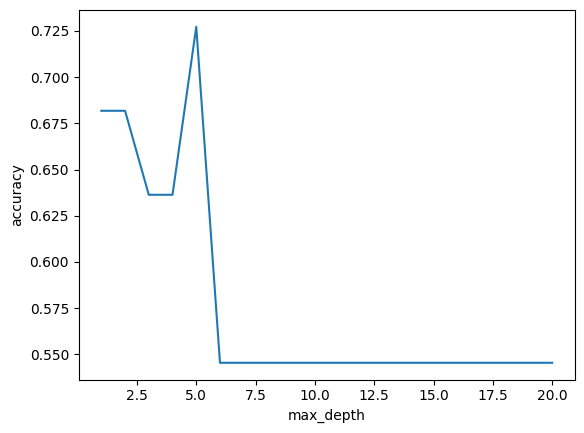

In [40]:
# Plot the accuracy vs depth
plt.plot(depths, acc_depth)
plt.xlabel('max_depth')
plt.ylabel('accuracy')

In [46]:
# Find the largest accuracy and the depth this occurs
acc_max = np.max(acc_depth)
print(acc_max)
best_depth = depths[np.argmax(acc_depth)]
best_depth

0.7272727272727273


5

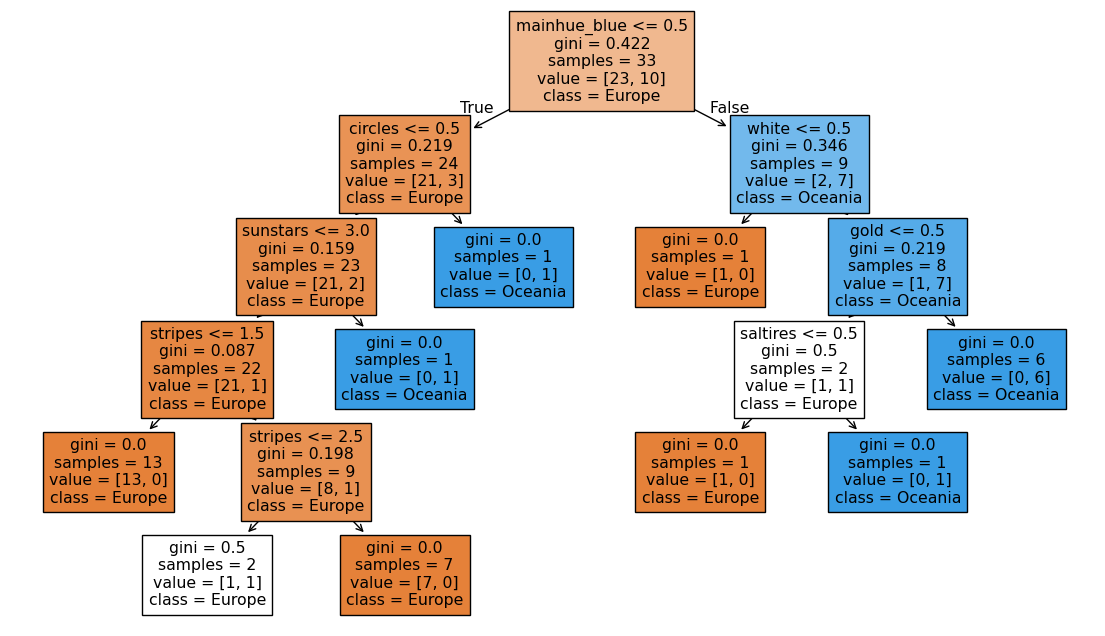

In [48]:
# Refit decision tree model with the highest accuracy and plot the decision tree
plt.figure(figsize=(14,8))
dtree = DecisionTreeClassifier(max_depth=best_depth, random_state=10)
dtree.fit(train_data, train_labels)
tree.plot_tree(dtree, feature_names = train_data.columns,  
               class_names = ['Europe', 'Oceania'], filled=True)
plt.show()

In [49]:
# Create a new list for the accuracy values of a pruned decision tree.
# Loop through the values of ccp and append the scores to the list
acc_pruned = []
ccp = np.logspace(-3, 0, num=20)
for i in ccp:
    dt_prune = DecisionTreeClassifier(random_state=1, max_depth=best_depth, ccp_alpha=i)
    dt_prune.fit(train_data, train_labels)
    acc_pruned.append(dt_prune.score(test_data, test_labels))

Text(0, 0.5, 'accuracy')

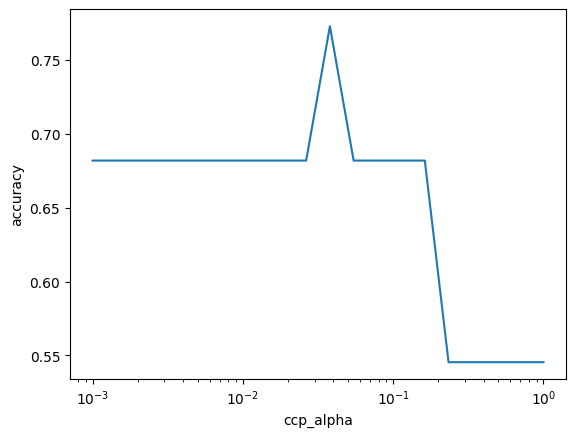

In [52]:
# Plot the accuracy vs ccp_alpha
plt.plot(ccp, acc_pruned)
plt.xscale('log')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')

In [54]:
# Find the largest accuracy and the ccp value this occurs
max_acc_pruned = np.max(acc_pruned)
print(max_acc_pruned)
best_ccp = ccp[np.argmax(acc_pruned)]
best_ccp

0.7727272727272727


np.float64(0.0379269019073225)

In [58]:
# Fit a decision tree model with the values for max_depth and ccp_alpha found above
dtree = DecisionTreeClassifier(max_depth=best_depth, random_state=10, ccp_alpha=best_ccp)
dtree.fit(train_data, train_labels)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

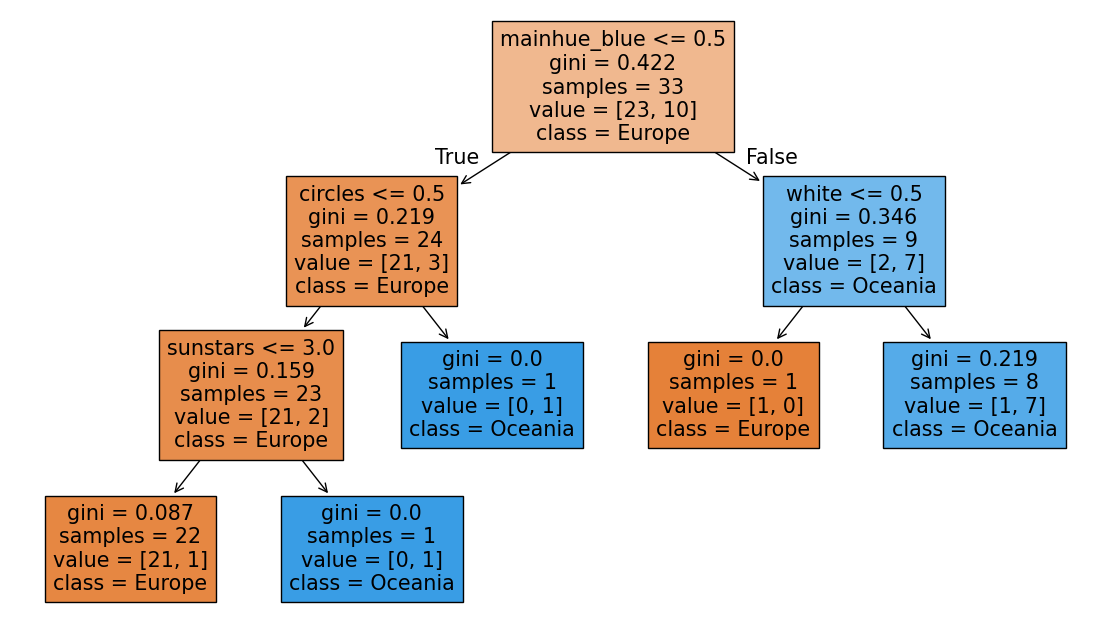

In [57]:
# Plot the final decision tree
plt.figure(figsize=(14,8))
tree.plot_tree(dtree, feature_names = train_data.columns,  
               class_names = ['Europe', 'Oceania'], filled=True)
plt.show()

### Predict income

In [2]:
col_names = ['age', 'workclass', 'fnlwgt','education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain','capital-loss', 'hours-per-week','native-country', 'income']
df = pd.read_csv('adult.data', header=None, names = col_names)

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
# Distribution of income
df.income.value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

In [3]:
# Clean columns by stripping extra whitespace for columns of type "object"
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

In [4]:
df['native-country'].value_counts(normalize=True)

native-country
United-States                 0.895857
Mexico                        0.019748
?                             0.017905
Philippines                   0.006081
Germany                       0.004207
Canada                        0.003716
Puerto-Rico                   0.003501
El-Salvador                   0.003255
India                         0.003071
Cuba                          0.002918
England                       0.002764
Jamaica                       0.002488
South                         0.002457
China                         0.002303
Italy                         0.002242
Dominican-Republic            0.002150
Vietnam                       0.002058
Guatemala                     0.001966
Japan                         0.001904
Poland                        0.001843
Columbia                      0.001812
Taiwan                        0.001566
Haiti                         0.001351
Iran                          0.001321
Portugal                      0.001136
Nicaragua 

In [5]:
# Create feature dataframe X with feature columns and dummy variables for categorical features
feature_cols = ['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'sex','race']

In [6]:
X = pd.get_dummies(df[feature_cols], drop_first=True)

In [7]:
# Create output variable y which is binary, 0 when income is less than 50k, 1 when it is greather than 50k
y = np.where(df.income == '<=50K', 0, 1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=.2)

In [9]:
# Instantiate random forest classifier, fit and score with default parameters
rf = RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.8189774297558728

In [10]:
#Tune the hyperparameter max_depth over a range from 1-25, save scores for test and train set
accuracy_train=[]
accuracy_test = []

In [11]:
depths = range(1, 26)

In [12]:
for d in depths:
  rf = RandomForestClassifier(max_depth=d)
  rf.fit(X_train, y_train)
  accuracy_train.append(accuracy_score(y_train, rf.predict(X_train)))
  accuracy_test.append(accuracy_score(y_test, rf.predict(X_test)))

In [13]:
#Find the best accuracy and at what depth that occurs
print(np.max(accuracy_test))
best_depth = depths[np.argmax(accuracy_test)]
best_depth

0.8346384154767388


13

Text(0, 0.5, 'accuracy')

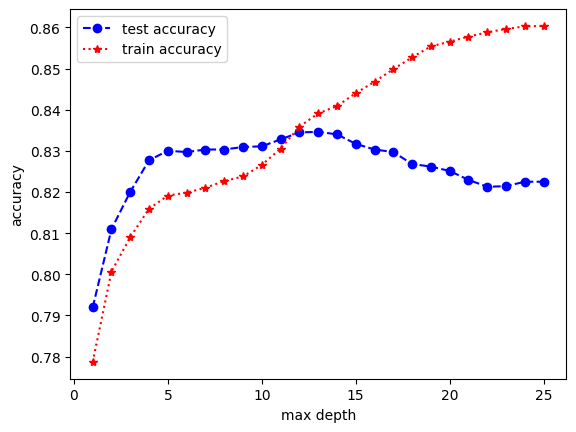

In [14]:
#Plot the accuracy scores for the test and train set over the range of depth values  
plt.plot(depths, accuracy_test, 'bo--',
         depths, accuracy_train,'r*:')
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')

In [15]:
#Save the best random forest model and save the feature importances in a dataframe
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",13
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
feat_imp_df = pd.DataFrame(zip(X_train.columns, best_rf.feature_importances_), 
                           columns=['feature', 'importance'])

feat_imp_df.sort_values('importance', ascending=False).iloc[0:5]

,feature,importance
1,capital-gain,0.357894
0,age,0.251130
3,hours-per-week,0.148637
2,capital-loss,0.138748
4,sex_Male,0.081025


In [17]:
# Create two new features, based on education and native country
df['education_bin'] = pd.cut(df['education-num'], [0,9,13,16], 
        labels=['HS or less', 'College to Bachelors', 'Masters or more'])

In [18]:
feature_cols.append('education_bin')
feature_cols.append('native-country')
feature_cols

['age',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'sex',
 'race',
 'education_bin',
 'native-country']

In [19]:
X = pd.get_dummies(df[feature_cols], drop_first=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=.2)

In [21]:
np.random.seed(0)
accuracy_train=[]
accuracy_test = []

In [22]:
for d in depths:
  rf = RandomForestClassifier(max_depth=d)
  rf.fit(X_train, y_train)
  accuracy_train.append(accuracy_score(y_train, rf.predict(X_train)))
  accuracy_test.append(accuracy_score(y_test, rf.predict(X_test)))

In [23]:
#Find the best max depth now with the additional two features
print(np.max(accuracy_test))
best_depth = depths[np.argmax(accuracy_test)]
best_depth

0.8492246276677414


18

Text(0, 0.5, 'accuracy')

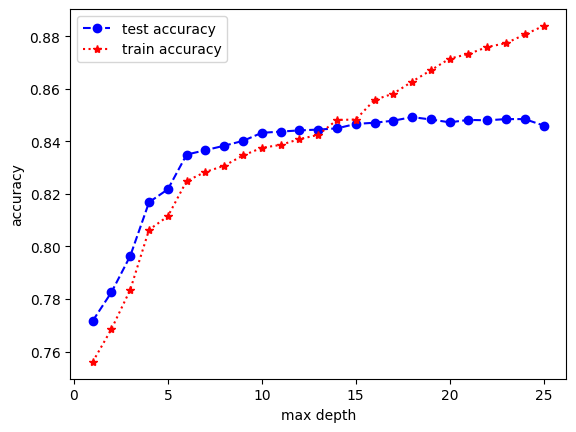

In [24]:
plt.plot(depths, accuracy_test, 'bo--',
         depths, accuracy_train,'r*:')
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')

In [25]:
# Save the best model and print the two features with the new feature set
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(X_train, y_train)

feat_imp_df = pd.DataFrame(zip(X_train.columns, best_rf.feature_importances_), 
                           columns=['feature', 'importance'])
feat_imp_df.sort_values('importance', ascending=False).iloc[0:5]

,feature,importance
1,capital-gain,0.259343
0,age,0.234158
3,hours-per-week,0.126079
10,education_bin_Masters or more,0.114425
2,capital-loss,0.095111
